In [1]:
"""
无人机可微分仿真训练 - Notebook 版本
支持交互式训练、可视化和调试
"""
import os
import sys
from types import SimpleNamespace
from collections import defaultdict
from datetime import datetime
from IPython.display import display, clear_output

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D
from tqdm.notebook import tqdm

# 导入项目模块
from drone_env import DroneSimulator
from model import Model
from loss import DroneLoss

# 从 train.py 导入训练器
from train import DroneTrainer, is_save_iter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# ==============================================================================
# 训练配置 - 使用 SimpleNamespace 模拟命令行参数
# ==============================================================================
args = SimpleNamespace(
    # 训练参数
    resume=None,                    # 恢复训练的模型路径 (None 或 './checkpoints/xxx.pth')
    batch_size=8,                  # 批量大小
    num_iters=100,                   # 训练迭代次数 (notebook 中可以设小一点)
    timesteps=100,                  # 每次迭代的模拟步数
    lr=1e-3,                        # 学习率
    grad_decay=0.4,                 # 梯度衰减系数 (GDecay)
    ctl_dt=1/15,                    # 控制时间步长 (秒), 参考项目标准值
    
    # 损失函数权重
    coef_v=1.0,                     # 速度跟踪损失权重
    coef_speed=0.0,                 # 速度损失权重 (legacy)
    coef_v_pred=2.0,                # 速度预测损失权重
    coef_collide=2.0,               # 碰撞损失权重
    coef_obj_avoidance=1.5,         # 障碍物回避损失权重
    coef_d_acc=0.01,                # 加速度正则化权重
    coef_d_jerk=0.001,              # 加加速度正则化权重
    coef_d_snap=0.0,                # snap正则化权重 (legacy)
    coef_ground_affinity=0.0,       # 地面亲和损失权重
    coef_bias=0.0,                  # 方向偏差损失权重
    window_size=30,                 # 速度平均窗口大小
    
    # 环境参数 - 渲染
    cam_angle=10,                   # 相机俯仰角
    image_height=48,                # 图像高度
    image_width=64,                 # 图像宽度
    mesh_path='./data/sample/sample4.obj',  # 障碍物网格路径
    num_samples=100000,             # 障碍物点云采样数
    
    # 环境参数 - 无人机物理
    margin_min=0.7,                 # 无人机安全半径最小值
    margin_max=1.0,                 # 无人机安全半径最大值
    init_p_range=2.0,               # 初始位置范围
    noise_std=0.04,                 # 环境扰动噪声标准差
    yaw_inertia=5.0,                # 偏航惯性
    yaw_ctl_delay=12.0,             # 偏航控制延迟
    pitch_ctl_delay=12.0,           # 俯仰控制延迟
    airmode_coef=0.5,               # Airmode 系数
    enable_airmode=True,            # 启用 Airmode
    disable_airmode=False,          # 禁用 Airmode (优先级高于 enable)
    
    # 模型参数
    no_odom=True,                  # 不使用里程计速度作为输入
    yaw_drift=False,                # 启用航向漂移
    debug=False,                    # 启用 anomaly detection
    
    # 保存参数
    save_dir='./checkpoints',
    log_dir='./logs'
)

print("训练配置:")
for k, v in vars(args).items():
    print(f"  {k}: {v}")

训练配置:
  resume: None
  batch_size: 8
  num_iters: 100
  timesteps: 100
  lr: 0.001
  grad_decay: 0.4
  ctl_dt: 0.06666666666666667
  coef_v: 1.0
  coef_speed: 0.0
  coef_v_pred: 2.0
  coef_collide: 2.0
  coef_obj_avoidance: 1.5
  coef_d_acc: 0.01
  coef_d_jerk: 0.001
  coef_d_snap: 0.0
  coef_ground_affinity: 0.0
  coef_bias: 0.0
  window_size: 30
  cam_angle: 10
  image_height: 48
  image_width: 64
  mesh_path: ./data/sample/sample4.obj
  num_samples: 100000
  margin_min: 0.7
  margin_max: 1.0
  init_p_range: 2.0
  noise_std: 0.04
  yaw_inertia: 5.0
  yaw_ctl_delay: 12.0
  pitch_ctl_delay: 12.0
  airmode_coef: 0.5
  enable_airmode: True
  disable_airmode: False
  no_odom: True
  yaw_drift: False
  debug: False
  save_dir: ./checkpoints
  log_dir: ./logs


In [3]:
# ==============================================================================
# 初始化训练器
# ==============================================================================
trainer = DroneTrainer(args)
print(f"\n模型参数量: {sum(p.numel() for p in trainer.model.parameters()):,}")

Using device: cuda
Loading mesh from: ./data/sample/sample4.obj
TensorBoard logs: ./logs/drone_train_20260112-171626

模型参数量: 513,920


开始训练...


Training:   0%|          | 0/100 [00:00<?, ?it/s]


✅ 训练完成!


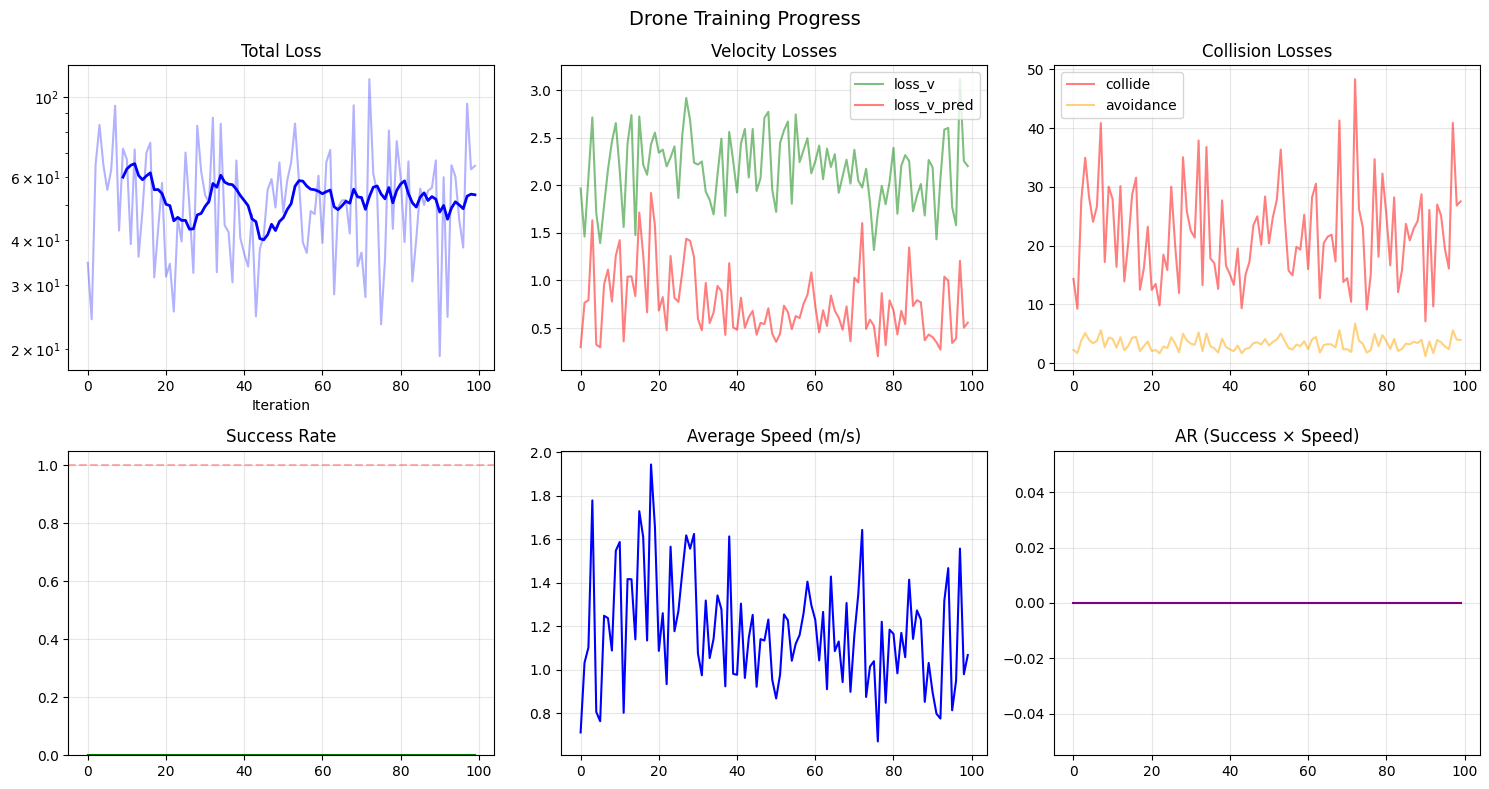

In [4]:
# ==============================================================================
# 交互式训练循环 (带实时可视化)
# ==============================================================================

def to_float(x):
    """将 tensor 或数值转换为 Python float"""
    if torch.is_tensor(x):
        return x.detach().cpu().item()
    return float(x)

# 训练记录
history = {
    'loss': [],
    'loss_v': [],
    'loss_v_pred': [],
    'loss_collide': [],
    'loss_obj_avoidance': [],
    'success_rate': [],
    'avg_speed': [],
    'ar': [],  # 成功率 × 平均速度
}

# 设置绘图
plt.ion()  # 开启交互模式
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Drone Training Progress', fontsize=14)

def update_plots(history, iteration):
    """更新训练曲线图"""
    for ax in axes.flat:
        ax.clear()
    
    iters = range(len(history['loss']))
    
    # 总损失
    axes[0, 0].plot(iters, history['loss'], 'b-', alpha=0.3)
    if len(history['loss']) >= 10:
        smooth = np.convolve(history['loss'], np.ones(10)/10, mode='valid')
        axes[0, 0].plot(range(9, len(history['loss'])), smooth, 'b-', linewidth=2)
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].set_xlabel('Iteration')
    axes[0, 0].set_yscale('log')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 速度跟踪损失
    axes[0, 1].plot(iters, history['loss_v'], 'g-', alpha=0.5, label='loss_v')
    axes[0, 1].plot(iters, history['loss_v_pred'], 'r-', alpha=0.5, label='loss_v_pred')
    axes[0, 1].set_title('Velocity Losses')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 碰撞/避障损失
    axes[0, 2].plot(iters, history['loss_collide'], 'r-', alpha=0.5, label='collide')
    axes[0, 2].plot(iters, history['loss_obj_avoidance'], 'orange', alpha=0.5, label='avoidance')
    axes[0, 2].set_title('Collision Losses')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # 成功率
    axes[1, 0].plot(iters, history['success_rate'], 'g-')
    axes[1, 0].set_title('Success Rate')
    axes[1, 0].set_ylim([0, 1.05])
    axes[1, 0].axhline(y=1.0, color='r', linestyle='--', alpha=0.3)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 平均速度
    axes[1, 1].plot(iters, history['avg_speed'], 'b-')
    axes[1, 1].set_title('Average Speed (m/s)')
    axes[1, 1].grid(True, alpha=0.3)
    
    # AR (成功率 × 平均速度) # AI写的，说是AR 代表 "Achievement Rate"，是成功率与平均速度的乘积，反映了无人机在任务中的整体表现。
    axes[1, 2].plot(iters, history['ar'], 'purple')
    axes[1, 2].set_title('AR (Success × Speed)')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    fig.canvas.draw()
    fig.canvas.flush_events()

# 训练主循环
print("开始训练...")
pbar = tqdm(range(args.num_iters), desc="Training")

for i in pbar:
    # 运行一个 episode
    loss, metrics, debug_data = trainer.run_episode(i)
    
    # 检查 NaN
    if torch.isnan(loss):
        print(f"\n !!! 损失出现 NaN 在项 {i}, stopping...")
        break
    
    # 反向传播
    trainer.optimizer.zero_grad()
    loss.backward()
    trainer.optimizer.step()
    trainer.scheduler.step()
    
    # 记录历史 (转换为 Python float)
    history['loss'].append(loss.item())
    history['loss_v'].append(to_float(metrics.get('loss_v', 0)))
    history['loss_v_pred'].append(to_float(metrics.get('loss_v_pred', 0)))
    history['loss_collide'].append(to_float(metrics.get('loss_collide', 0)))
    history['loss_obj_avoidance'].append(to_float(metrics.get('loss_obj_avoidance', 0)))
    history['success_rate'].append(to_float(metrics.get('success_rate', 0)))
    history['avg_speed'].append(to_float(metrics.get('avg_speed', 0)))
    history['ar'].append(to_float(metrics.get('ar', 0)))
    
    # 更新进度条
    pbar.set_postfix({
        'loss': f"{loss.item():.3f}",
        'sr': f"{to_float(metrics.get('success_rate', 0)):.2f}",
        'ar': f"{to_float(metrics.get('ar', 0)):.2f}"
    })
    
    # 定期更新图表 (每 10 次)
    if (i + 1) % 10 == 0:
        update_plots(history, i)
    
    # 定期保存模型
    if is_save_iter(i):
        save_path = os.path.join(args.save_dir, f'model_iter{i+1}.pth')
        torch.save(trainer.model.state_dict(), save_path)
        print(f"\n💾 Model saved to {save_path}")

# 最终更新图表
update_plots(history, args.num_iters)
plt.ioff()
print("\n✅ 训练完成!")

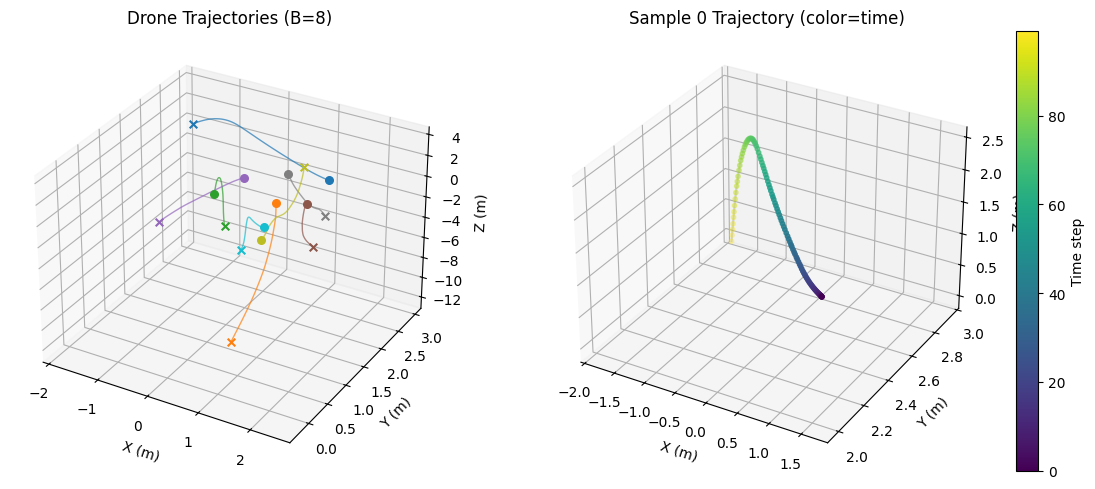


📊 Episode 统计:
  成功率: 0.00%
  平均速度: 0.77 m/s
  最大速度: 1.37 m/s
  AR: 0.000


In [5]:
# ==============================================================================
# 单次 Episode 可视化 (3D 轨迹)
# ==============================================================================

# 运行一个 episode 获取轨迹数据
with torch.no_grad():
    trainer.model.eval()
    _, metrics, (p_history, v_history, act_history, vid) = trainer.run_episode(0)
    trainer.model.train()

p_np = p_history.cpu().numpy()  # (T, B, 3)
T, B, _ = p_np.shape

# 绘制 3D 轨迹
fig = plt.figure(figsize=(12, 5))

# 子图1: 所有轨迹
ax1 = fig.add_subplot(121, projection='3d')
colors = plt.cm.tab10(np.linspace(0, 1, min(B, 10)))

for b in range(min(B, 10)):
    traj = p_np[:, b, :]
    ax1.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
             color=colors[b], alpha=0.7, linewidth=1)
    ax1.scatter(traj[0, 0], traj[0, 1], traj[0, 2], 
                color=colors[b], marker='o', s=30, label=f'Start {b}')
    ax1.scatter(traj[-1, 0], traj[-1, 1], traj[-1, 2], 
                color=colors[b], marker='x', s=30)

ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_zlabel('Z (m)')
ax1.set_title(f'Drone Trajectories (B={B})')

# 子图2: 单个轨迹详细视图
ax2 = fig.add_subplot(122, projection='3d')
sample_idx = 0
traj = p_np[:, sample_idx, :]

# 用颜色表示时间
scatter = ax2.scatter(traj[:, 0], traj[:, 1], traj[:, 2], 
                      c=np.arange(T), cmap='viridis', s=10)
ax2.plot(traj[:, 0], traj[:, 1], traj[:, 2], 'gray', alpha=0.3)

ax2.set_xlabel('X (m)')
ax2.set_ylabel('Y (m)')
ax2.set_zlabel('Z (m)')
ax2.set_title(f'Sample {sample_idx} Trajectory (color=time)')

plt.colorbar(scatter, ax=ax2, label='Time step')
plt.tight_layout()
plt.show()

# 输出统计
print(f"\n📊 Episode 统计:")
print(f"  成功率: {metrics.get('success_rate', 0):.2%}")
print(f"  平均速度: {metrics.get('avg_speed', 0):.2f} m/s")
print(f"  最大速度: {metrics.get('max_speed', 0):.2f} m/s")
print(f"  AR: {metrics.get('ar', 0):.3f}")

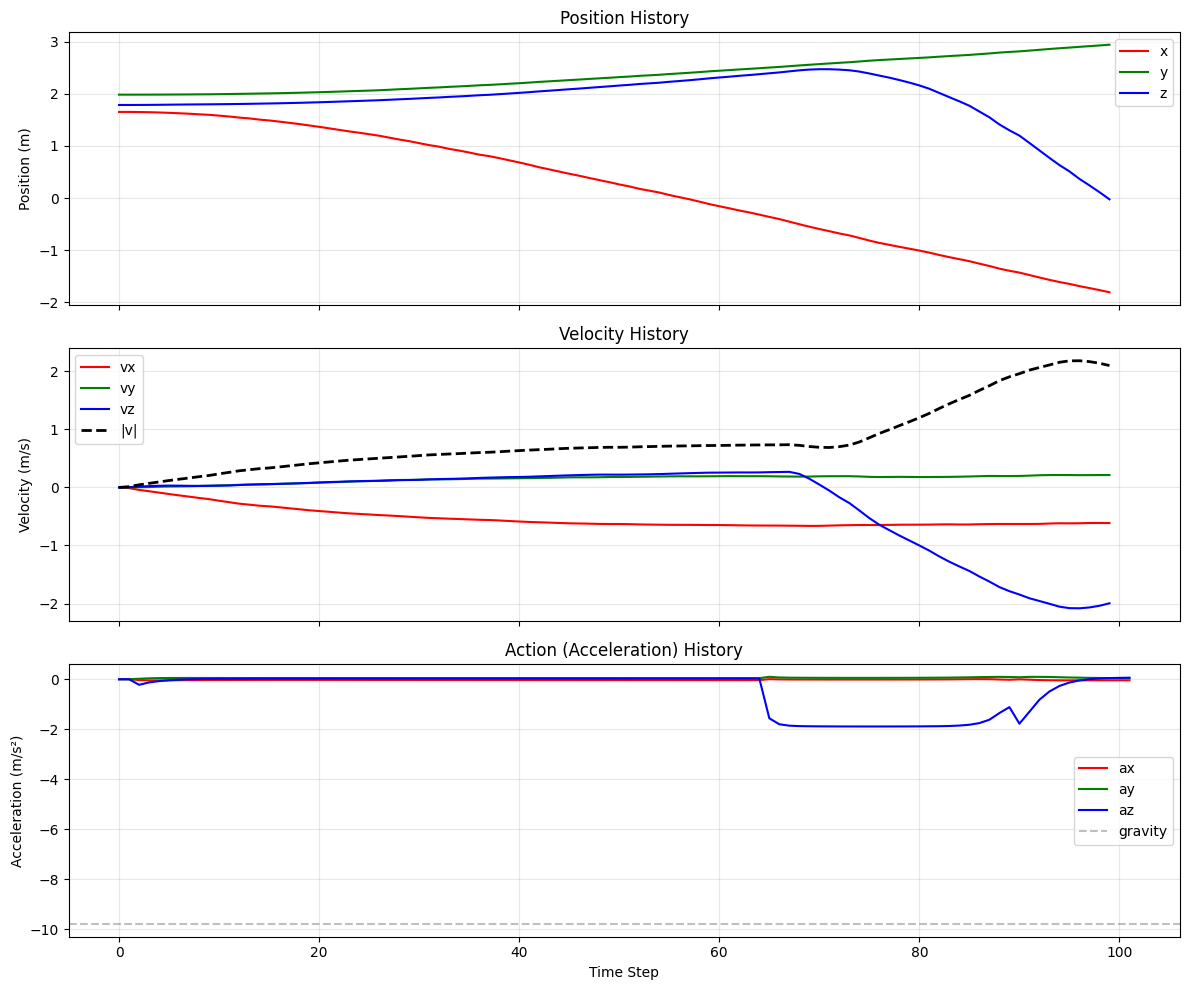

In [6]:
# ==============================================================================
# 状态历史可视化 (位置、速度、动作)
# ==============================================================================

sample_idx = 0  # 选择要可视化的样本

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 位置历史
p_sample = p_history[:, sample_idx].cpu().numpy()
axes[0].plot(p_sample[:, 0], label='x', color='r')
axes[0].plot(p_sample[:, 1], label='y', color='g')
axes[0].plot(p_sample[:, 2], label='z', color='b')
axes[0].set_ylabel('Position (m)')
axes[0].set_title('Position History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 速度历史
v_sample = v_history[:, sample_idx].cpu().numpy()
axes[1].plot(v_sample[:, 0], label='vx', color='r')
axes[1].plot(v_sample[:, 1], label='vy', color='g')
axes[1].plot(v_sample[:, 2], label='vz', color='b')
speed = np.linalg.norm(v_sample, axis=1)
axes[1].plot(speed, label='|v|', color='k', linestyle='--', linewidth=2)
axes[1].set_ylabel('Velocity (m/s)')
axes[1].set_title('Velocity History')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 动作历史
act_sample = act_history[:, sample_idx].cpu().numpy()
axes[2].plot(act_sample[:, 0], label='ax', color='r')
axes[2].plot(act_sample[:, 1], label='ay', color='g')
axes[2].plot(act_sample[:, 2], label='az', color='b')
axes[2].axhline(y=-9.8, color='gray', linestyle='--', alpha=0.5, label='gravity')
axes[2].set_ylabel('Acceleration (m/s²)')
axes[2].set_xlabel('Time Step')
axes[2].set_title('Action (Acceleration) History')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# ==============================================================================
# 深度图可视化 (如果有记录)
# ==============================================================================

if vid and len(vid) > 0:
    # vid 是深度图列表
    vid_np = torch.stack(vid).cpu().numpy()
    
    # 显示多帧
    n_frames = min(8, len(vid_np))
    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    axes = axes.flatten()
    
    frame_indices = np.linspace(0, len(vid_np)-1, n_frames, dtype=int)
    
    for idx, frame_idx in enumerate(frame_indices):
        im = axes[idx].imshow(vid_np[frame_idx], cmap='viridis')
        axes[idx].set_title(f'Frame {frame_idx}')
        axes[idx].axis('off')
    
    plt.suptitle('Depth Images from Episode')
    plt.tight_layout()
    plt.show()
else:
    print("没有记录深度图帧 (vid 为空)")

没有记录深度图帧 (vid 为空)


In [8]:
# ==============================================================================
# 保存最终模型
# ==============================================================================

final_save_path = os.path.join(args.save_dir, 'model_notebook_final.pth')
torch.save(trainer.model.state_dict(), final_save_path)
print(f"✅ 最终模型已保存到: {final_save_path}")

# 保存训练历史
import json
history_path = os.path.join(args.log_dir, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"📊 训练历史已保存到: {history_path}")

✅ 最终模型已保存到: ./checkpoints/model_notebook_final.pth
📊 训练历史已保存到: ./logs/training_history.json
